### [Anchoring VWAP Like Institutions](https://medium.com/@crisvelasquez/anchoring-vwap-like-institutions-bab2f015dd55)

> Build the most-used trading indicator by institutional traders across time frames, with volume and volatility overlays.

**_Anchored VWAP_** is a key reference point for institutions to measure where fair value sits, at least from a trading perspective.

This indicator locks in the true average price, weighted by volume, starting from any event or the session open.

Large traders use anchored VWAP to see where money has actually changed hands since an event, a gap, or a trend reversal.

Anchor VWAP gives signs of regime change, supply and demand, and crowd positioning.

Most price tools only track momentum or moving averages. Anchored VWAP shows where the bulk of capital is committed.

Anchored VWAP tracks the true average price paid, weighted by volume, since a specific starting point.

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
!pip install -qU yfinance

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from mpl_toolkits.axes_grid1 import make_axes_locatable

# ── adjustable settings
TICKER       = "TSLA"
TIMEFRAMES   = [
    ("2y",  "1d"),
    ("1y",  "1h"),
    ("60d", "15m"),
    ("1mo", "5m")
]

SCALE_FACTOR = 0.5   # scales volume bar height; ↑ = taller bars, ↓ = shorter bars
ALPHA_VOL    = 0.6   # volume bar opacity;   ↑ = more opaque,  ↓ = more transparent
ATR_LEN      = 14    # ATR lookback length;  ↑ = smoother ATR,     ↓ = more sensitive ATR
RVOL_LEN     = 30    # rolling window for avg volume; ↑ = slower baseline, ↓ = faster baseline
RVOL_THR     = 2     # relative-volume flag threshold; ↑ = fewer bars flagged, ↓ = more flagged
HIST_BINS    = 50    # number of bins in price histogram; ↑ = finer resolution, ↓ = coarser

EXTRA_RIGHT  = 0.10   # % of total time span added as blank room on right; ↑ = more blank space, ↓ = less
PAD_RIGHT    = 0.65   # fraction of axes width between price plot & histogram; ↑ = wider gap, ↓ = narrower

# Anchor VWAP here. Use None to anchor at dataset start.
ANCHOR_DATE  = None   # e.g. "2023-01-15"; set a date for custom VWAP start, None defaults to first timestamp

In [4]:
# ---------- helpers
def download_ohlc(ticker: str, period: str, interval: str) -> pd.DataFrame:
    df = yf.download(
        ticker, period=period, interval=interval,
        auto_adjust=True, progress=False
    )
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df.columns = df.columns.map(str.title)
    return df.dropna(subset=["Open", "High", "Low", "Close"])

def anchored_vwap(df: pd.DataFrame, anchor_ts: pd.Timestamp) -> pd.Series:
    tp   = (df["High"] + df["Low"] + df["Close"]) / 3
    mask = df.index >= anchor_ts
    cum_pv = (tp * df["Volume"]).where(mask).cumsum()
    cum_v  = df["Volume"].where(mask).cumsum()
    return cum_pv / cum_v

def atr(high, low, close, length: int = 14) -> pd.Series:
    tr = pd.concat([
        high - low,
        (high - close.shift()).abs(),
        (low  - close.shift()).abs()
    ], axis=1).max(axis=1)
    return tr.rolling(length).mean()

In [5]:
# ---------- panel plot
def plot_panel(ax_p, df: pd.DataFrame, title_suffix: str = "", anchor_date: str = None):
    # determine anchor timestamp
    tz = df.index.tz
    if anchor_date:
        anchor_ts = pd.to_datetime(anchor_date)
        if tz:
            anchor_ts = anchor_ts.tz_localize(tz)
    else:
        anchor_ts = df.index[0]

    # clamp to data range
    if anchor_ts < df.index[0] or anchor_ts > df.index[-1]:
        anchor_ts = df.index[0]

    anchor_label = anchor_ts.strftime("%Y-%m-%d")

    # compute indicators
    df["AVWAP"] = anchored_vwap(df, anchor_ts)
    df["ATR"]   = atr(df["High"], df["Low"], df["Close"], ATR_LEN)
    df["RVOL"]  = df["Volume"] / df["Volume"].rolling(RVOL_LEN).mean()

    # blank space on the right
    span = df.index[-1] - df.index[0]
    ax_p.set_xlim(df.index[0], df.index[-1] + span * EXTRA_RIGHT)

    # main price series
    ax_p.plot(df.index, df["Close"], lw=1.1, label="Close")
    ax_p.plot(df.index, df["AVWAP"], lw=1.3, label=f"AnchVWAP ({anchor_label})")
    ax_p.plot(
        df.index, df["AVWAP"] + df["ATR"],
        ls="--", lw=0.8, color="gray", alpha=0.8, label="+1 ATR"
    )
    ax_p.plot(
        df.index, df["AVWAP"] - df["ATR"],
        ls="--", lw=0.8, color="gray", alpha=0.8, label="-1 ATR"
    )
    ax_p.set_ylabel("Price")
    ax_p.legend(loc="upper left", fontsize="small")

    # volume bars
    ax_v = ax_p.twinx()
    delta_days = df.index.to_series().diff().median() / pd.Timedelta(days=1)
    bar_w = delta_days * 0.8
    up   = df["Close"] >= df["Open"]
    down = ~up
    vol  = df["Volume"] * SCALE_FACTOR

    ax_v.bar(
        df.index[up & (df["RVOL"] < RVOL_THR)],
        vol[up & (df["RVOL"] < RVOL_THR)],
        width=bar_w, color="g", alpha=ALPHA_VOL
    )
    ax_v.bar(
        df.index[down & (df["RVOL"] < RVOL_THR)],
        vol[down & (df["RVOL"] < RVOL_THR)],
        width=bar_w, color="r", alpha=ALPHA_VOL
    )
    ax_v.bar(
        df.index[up & (df["RVOL"] >= RVOL_THR)],
        vol[up & (df["RVOL"] >= RVOL_THR)],
        width=bar_w, color="lime", alpha=ALPHA_VOL
    )
    ax_v.bar(
        df.index[down & (df["RVOL"] >= RVOL_THR)],
        vol[down & (df["RVOL"] >= RVOL_THR)],
        width=bar_w, color="orange", alpha=ALPHA_VOL
    )
    ax_v.set_ylabel("Vol (scaled)")

    # histogram with bigger pad
    divider = make_axes_locatable(ax_p)
    ax_h = divider.append_axes("right", size="9%", pad=PAD_RIGHT, sharey=ax_p)
    counts, edges = np.histogram(df["Close"], bins=HIST_BINS)
    centers = (edges[:-1] + edges[1:]) / 2
    ax_h.barh(centers, counts, color="cyan", alpha=0.6)
    ax_h.invert_xaxis()
    ax_h.xaxis.set_ticks_position("top")
    ax_h.xaxis.set_label_position("top")
    ax_h.tick_params(axis="x", colors="w", bottom=False, labelbottom=False)
    ax_h.set_xlabel("Freq")
    ax_h.yaxis.set_visible(False)
    ax_h.set_facecolor("black")

    # datetime axis
    loc = mdates.AutoDateLocator()
    fmt = mdates.ConciseDateFormatter(loc)
    ax_p.xaxis.set_major_locator(loc)
    ax_p.xaxis.set_major_formatter(fmt)
    plt.setp(ax_p.get_xticklabels(), rotation=45, ha="right")

    ax_p.set_title(title_suffix, fontsize="medium")

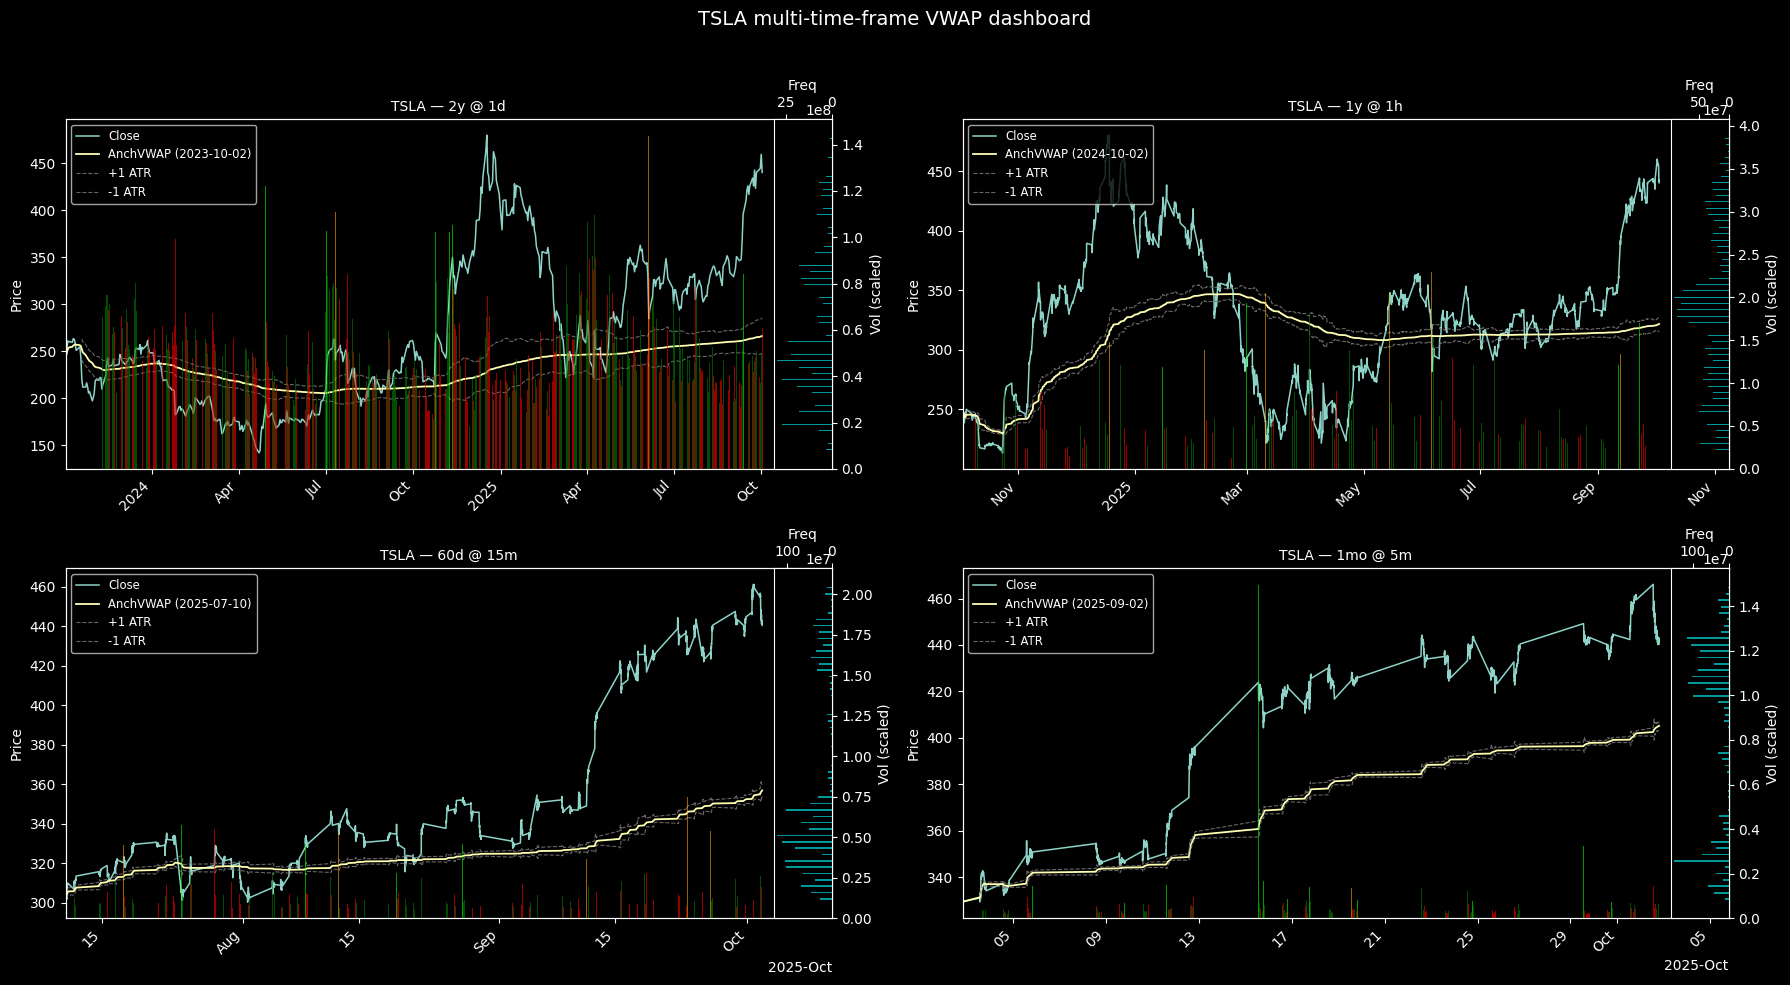

In [6]:
# ---------- build dashboard
plt.style.use("dark_background")
fig, axes = plt.subplot_mosaic("AB\nCD", figsize=(18, 10))

for ax, (period, interval) in zip(axes.values(), TIMEFRAMES):
    data = download_ohlc(TICKER, period, interval)
    plot_panel(
        ax, data,
        title_suffix=f"{TICKER} — {period} @ {interval}",
        anchor_date=ANCHOR_DATE
    )

fig.suptitle(f"{TICKER} multi-time-frame VWAP dashboard", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()